<a href="https://colab.research.google.com/github/singhm8755/7150CEM-Ecommerce-Returns-CLV/blob/main/4_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL TRAINING FOR RETURN RISK PREDICTION

SECTION 1: DATA LOADING AND PREPARATION
----------------------------------------------------------------------

Dataset loaded: 120,000 transactions
Return rate: 29.5%

Features selected for modeling:
  Categorical: ['product_category', 'payment_method', 'device_type', 'customer_segment']
  Numeric: ['order_value_gbp', 'click_depth', 'time_on_page_seconds', 'product_page_visits', 'customer_tenure_days', 'order_frequency_12m']

Feature matrix shape: (120000, 10)
Target distribution:
returned
0    84651
1    35349
Name: count, dtype: int64

SECTION 2: TRAIN-TEST SPLIT
----------------------------------------------------------------------

Training set size: 96,000 (80.0%)
Test set size: 24,000 (20.0%)

Training set return rate: 0.2945729166666667
Test set return rate: 0.2945833333333333

Features scaled using StandardS

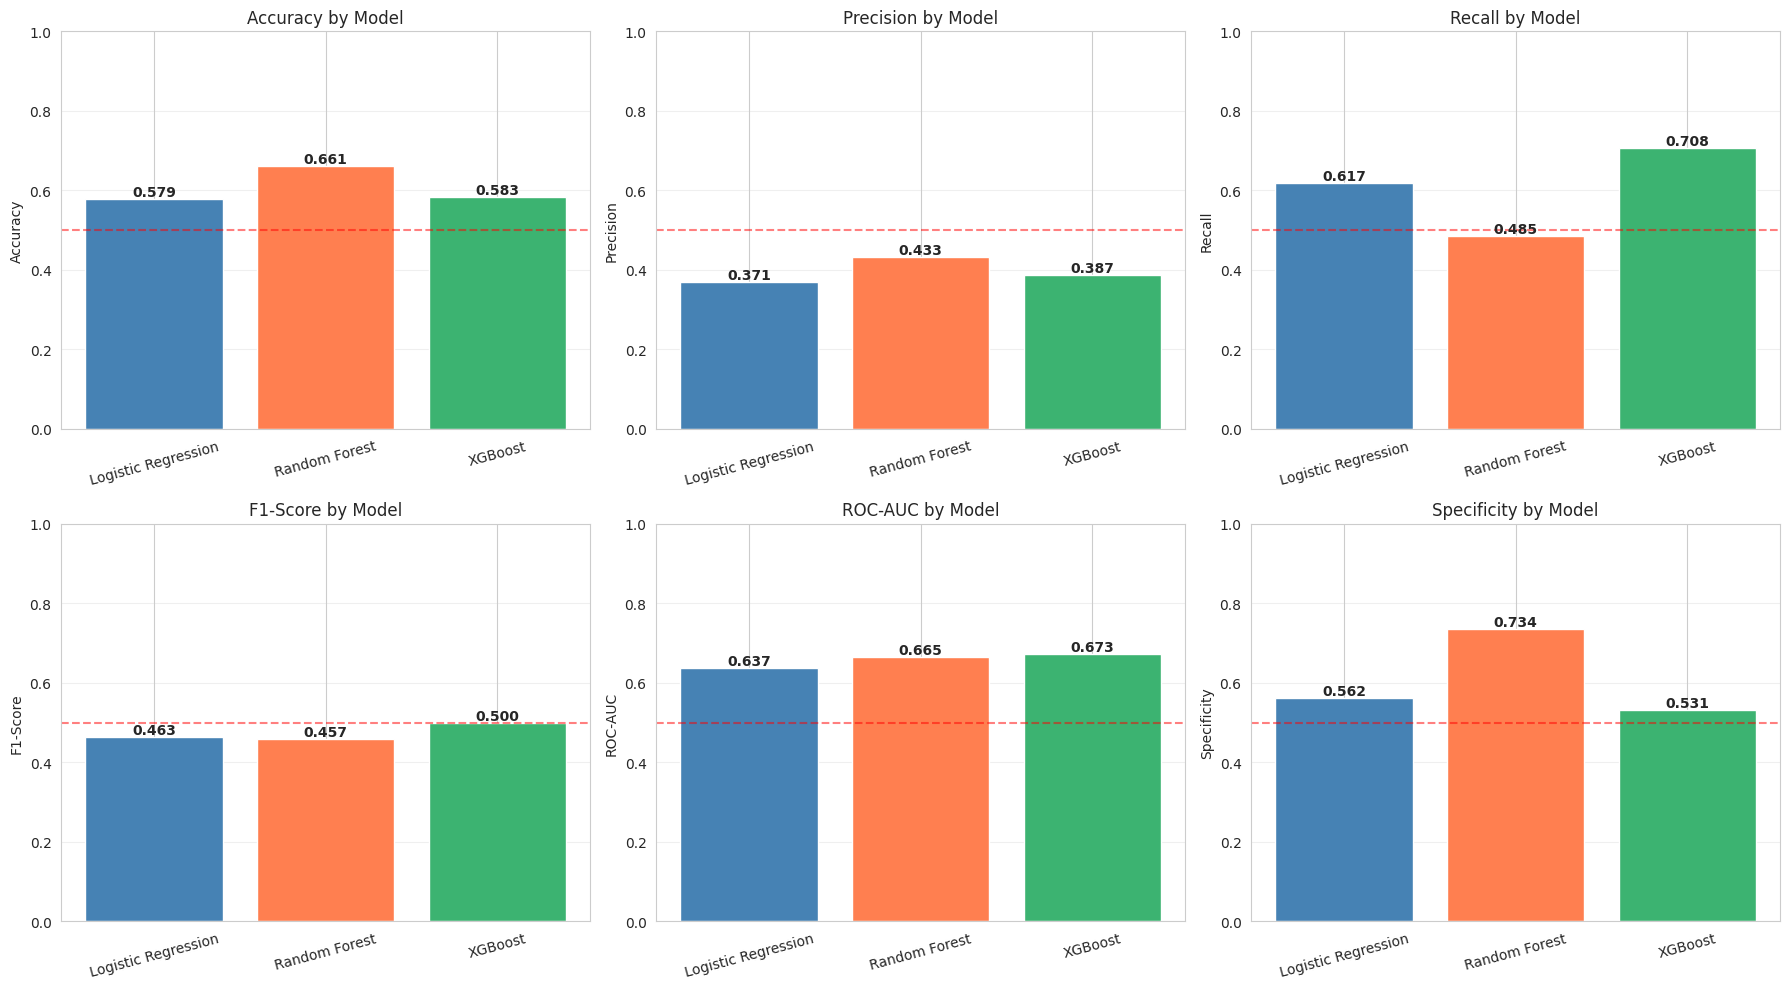

Saved: 07_model_comparison.png



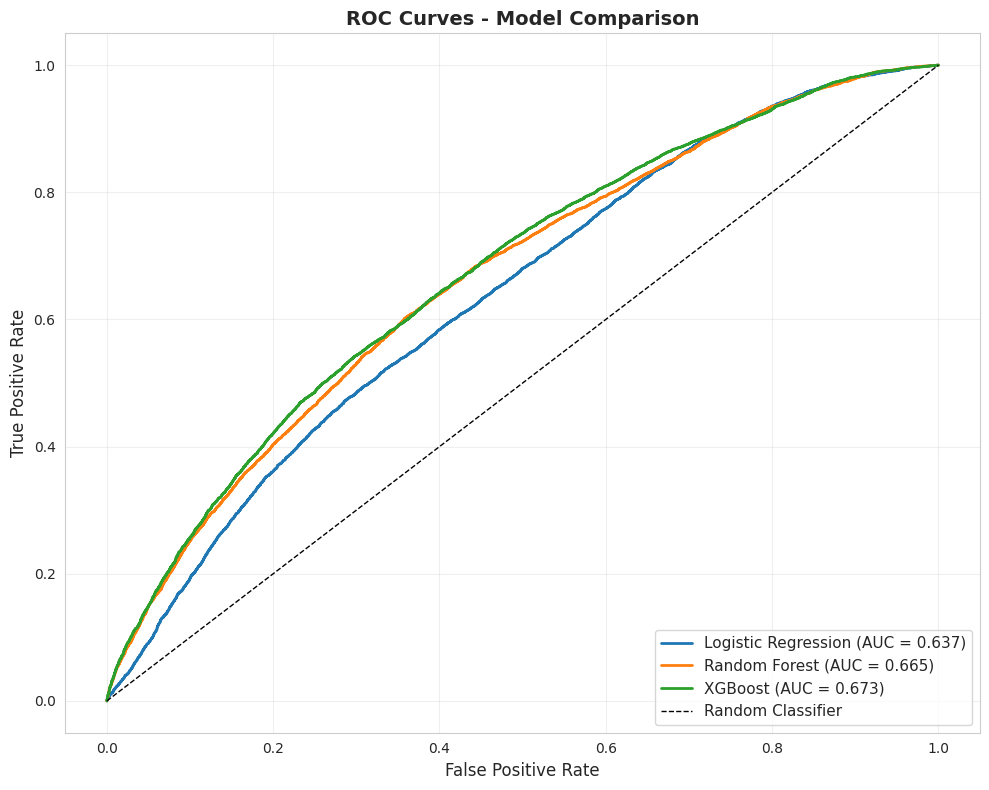

Saved: 08_roc_curves.png



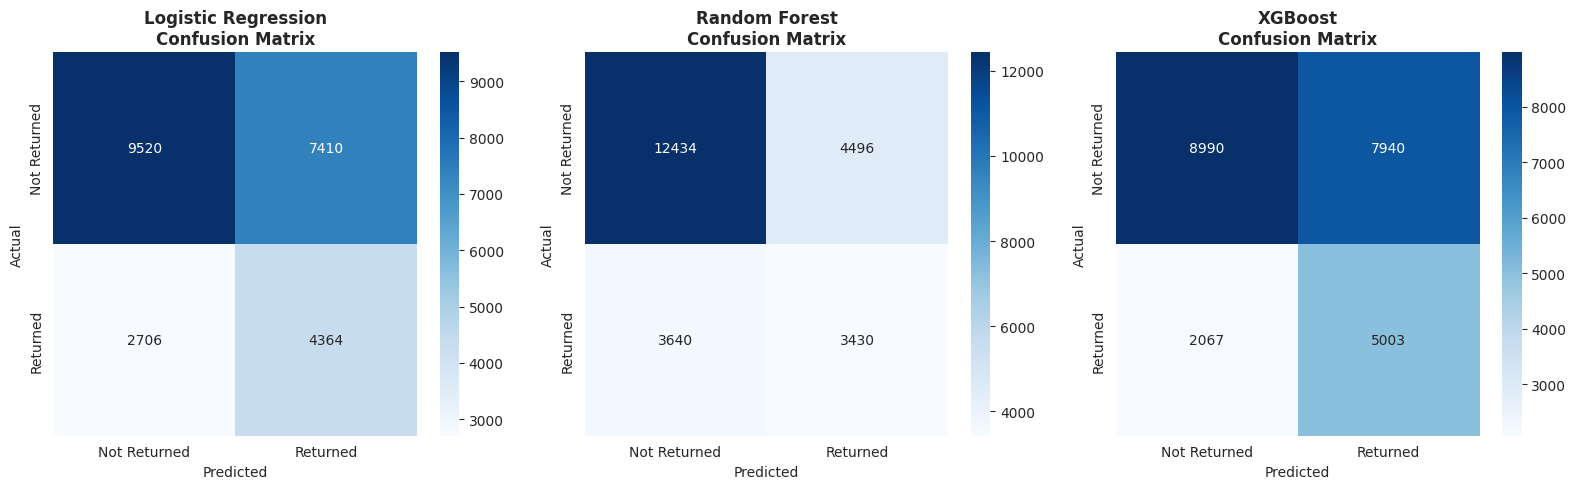

Saved: 09_confusion_matrices.png

SECTION 10: FEATURE IMPORTANCE ANALYSIS

Random Forest - Top 10 Important Features:
                 Feature  Importance
             click_depth    0.161009
    customer_tenure_days    0.148620
         order_value_gbp    0.133288
    time_on_page_seconds    0.132334
     product_page_visits    0.120449
     order_frequency_12m    0.112263
product_category_encoded    0.097735
customer_segment_encoded    0.034326
  payment_method_encoded    0.031018
     device_type_encoded    0.028958

XGBoost - Top 10 Important Features:
                 Feature  Importance
product_category_encoded    0.234133
             click_depth    0.200123
     order_frequency_12m    0.166244
     product_page_visits    0.140018
customer_segment_encoded    0.083165
  payment_method_encoded    0.053968
    customer_tenure_days    0.038777
     device_type_encoded    0.033875
    time_on_page_seconds    0.025498
         order_value_gbp    0.024199



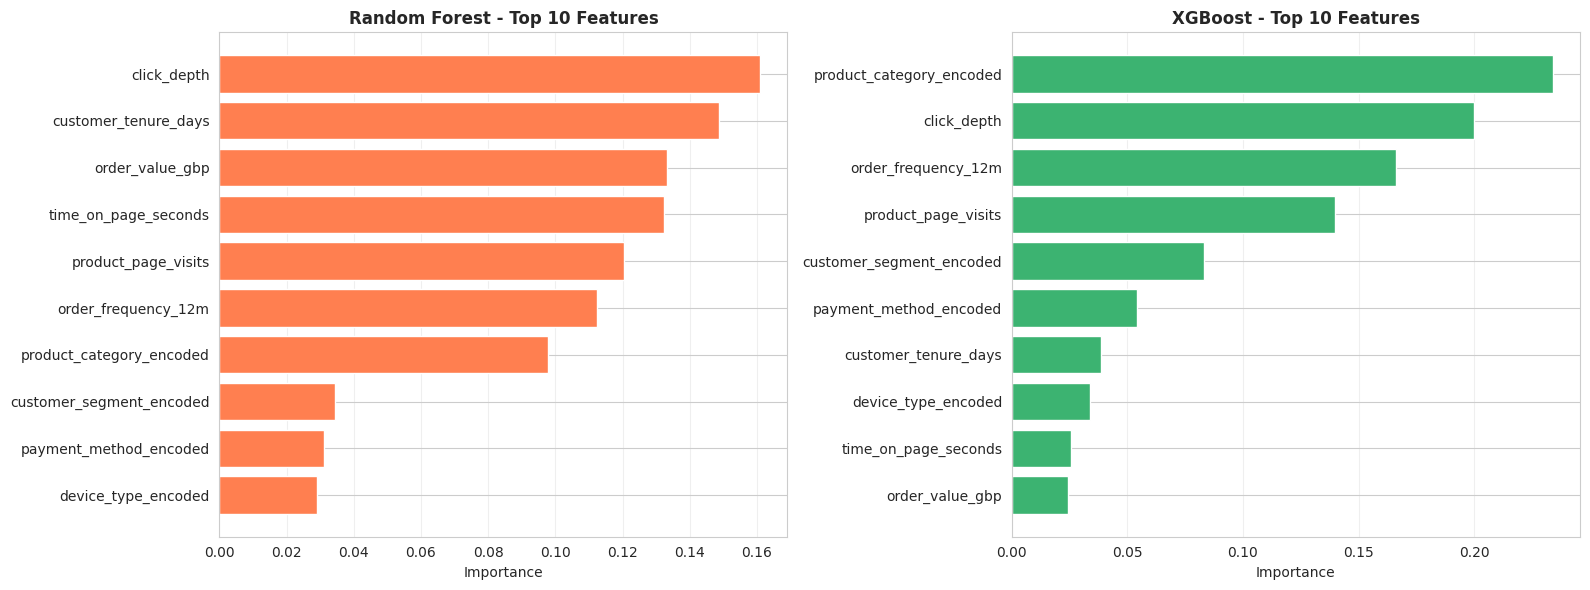

Saved: 10_feature_importance.png

SECTION 11: SAVING TRAINED MODELS

Models saved:
  - Logistic Regression: /content/drive/MyDrive/7150CEM_Project/models/logistic_regression.pkl
  - Random Forest: /content/drive/MyDrive/7150CEM_Project/models/random_forest.pkl
  - XGBoost: /content/drive/MyDrive/7150CEM_Project/models/xgboost.pkl
  - Feature Scaler: /content/drive/MyDrive/7150CEM_Project/models/scaler.pkl
  - Label Encoders: /content/drive/MyDrive/7150CEM_Project/models/label_encoders.pkl

MODEL TRAINING COMPLETE

Best performing model: XGBoost
  F1-Score: 0.5000
  ROC-AUC:  0.6726

Next step: Integrate best model into CLV analysis and business impact simulation



In [ ]:
# Model Training for Return Risk Prediction
# This notebook trains and evaluates classification models on imbalanced data
# using SMOTE/ADASYN techniques and comprehensive performance metrics.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, recall_score, accuracy_score,
                             precision_score)
from imblearn.over_sampling import SMOTE, ADASYN
import joblib
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 70)
print("MODEL TRAINING FOR RETURN RISK PREDICTION")
print("=" * 70)
print()

# ============================================================================
# Section 1: Data Loading and Preparation
# ============================================================================

print("SECTION 1: DATA LOADING AND PREPARATION")
print("-" * 70)
print()

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/7150CEM_Project/data/synthetic_ecommerce.csv')
print(f"Dataset loaded: {len(df):,} transactions")
print(f"Return rate: {df['returned'].mean():.1%}")
print()

# Select features for modeling
# Based on EDA findings, we include behavioral, transactional, and product features
categorical_features = ['product_category', 'payment_method', 'device_type', 'customer_segment']
numeric_features = ['order_value_gbp', 'click_depth', 'time_on_page_seconds',
                   'product_page_visits', 'customer_tenure_days', 'order_frequency_12m']

print("Features selected for modeling:")
print(f"  Categorical: {categorical_features}")
print(f"  Numeric: {numeric_features}")
print()

# Encode categorical variables using Label Encoding
# This converts text categories to numeric values for model training
label_encoders = {}
df_encoded = df.copy()

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Prepare feature matrix X and target vector y
feature_cols = [col + '_encoded' for col in categorical_features] + numeric_features
X = df_encoded[feature_cols]
y = df_encoded['returned']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print()

# ============================================================================
# Section 2: Train-Test Split
# ============================================================================

print("SECTION 2: TRAIN-TEST SPLIT")
print("-" * 70)
print()

# Split data into training and testing sets with stratification
# Stratification ensures both sets have the same proportion of returns
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print()
print("Training set return rate:", y_train.mean())
print("Test set return rate:", y_test.mean())
print()

# Feature scaling
# Standardize features to have mean 0 and standard deviation 1
# This improves convergence for logistic regression and helps with distance-based methods
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print()

# ============================================================================
# Section 3: Handling Class Imbalance with SMOTE
# ============================================================================

print("SECTION 3: HANDLING CLASS IMBALANCE")
print("-" * 70)
print()

# Apply SMOTE to balance the training data
# SMOTE creates synthetic examples of the minority class (returns)
# This helps the model learn patterns in returned transactions
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Original training set class distribution:")
print(y_train.value_counts())
print()
print("After SMOTE resampling:")
print(pd.Series(y_train_smote).value_counts())
print()

# Alternative: ADASYN (Adaptive Synthetic Sampling)
# ADASYN focuses more on harder-to-learn minority examples
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

print("After ADASYN resampling:")
print(pd.Series(y_train_adasyn).value_counts())
print()

# For this project, we will proceed with SMOTE
# Both methods will be compared in evaluation
X_train_resampled = X_train_smote
y_train_resampled = y_train_smote

# ============================================================================
# Section 4: Model Training - Logistic Regression
# ============================================================================

print("SECTION 4: MODEL TRAINING")
print("-" * 70)
print()

print("Training Model 1: Logistic Regression")
print("-" * 40)

# Logistic Regression serves as an interpretable baseline model
# Hyperparameter grid for tuning
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

# Use stratified k-fold cross-validation
# k is set to 5 based on dataset size and computational constraints
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV performs exhaustive search over the parameter grid
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_resampled, y_train_resampled)

# Best logistic regression model
lr_best = lr_grid.best_estimator_
print("Best parameters:", lr_grid.best_params_)
print("Best CV F1-score:", lr_grid.best_score_)
print()

# ============================================================================
# Section 5: Model Training - Random Forest
# ============================================================================

print("Training Model 2: Random Forest")
print("-" * 40)

# Random Forest can capture non-linear relationships
# and provides feature importance rankings

rf_param_grid = {
    'n_estimators': [150, 250],          # 2 values
    'max_depth': [12, 20],               # 2 values
    'min_samples_split': [2, 5],         # 2 values
    'class_weight': ['balanced']         # 1 value
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv_strategy,          # 3‑fold CV
    scoring='f1',
    n_jobs=1,                # avoid double parallelism
    verbose=1
)

rf_grid.fit(X_train_resampled, y_train_resampled)

rf_best = rf_grid.best_estimator_
print("Best parameters:", rf_grid.best_params_)
print("Best CV F1-score:", rf_grid.best_score_)
print()


# ============================================================================
# Section 6: Model Training - XGBoost
# ============================================================================

print("Training Model 3: XGBoost")
print("-" * 40)

# XGBoost is effective for complex feature interactions
# and typically achieves strong predictive performance
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Calculate scale_pos_weight for class imbalance
# This parameter helps XGBoost handle imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
    xgb_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_resampled, y_train_resampled)

xgb_best = xgb_grid.best_estimator_
print("Best parameters:", xgb_grid.best_params_)
print("Best CV F1-score:", xgb_grid.best_score_)
print()

# ============================================================================
# Section 7: Model Evaluation
# ============================================================================

print("=" * 70)
print("SECTION 7: MODEL EVALUATION ON TEST SET")
print("=" * 70)
print()

# Dictionary to store all models
models = {
    'Logistic Regression': lr_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best
}

# Dictionary to store evaluation results
results = []

for model_name, model in models.items():
    print(f"\nEvaluating: {model_name}")
    print("-" * 70)

    # Generate predictions on test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate all metrics from proposal
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Calculate specificity (True Negative Rate)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Specificity': specificity
    })

    # Print metrics
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    print(f"ROC-AUC:     {roc_auc:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print()

# ============================================================================
# Section 8: Results Comparison
# ============================================================================

print("=" * 70)
print("SECTION 8: MODEL COMPARISON")
print("=" * 70)
print()

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print(results_df.to_string())
print()

# Check against proposal targets
print("Performance Against Proposal Targets:")
print("-" * 70)
targets = {
    'F1-Score': 0.72,
    'ROC-AUC': 0.80,
    'Recall': 0.70,
    'Specificity': 0.80
}

for metric, target in targets.items():
    best_model = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    status = "ACHIEVED" if best_value >= target else "NOT MET"
    print(f"{metric:15s}: Target {target:.2f}, Best {best_value:.4f} ({best_model}) - {status}")

print()

# Save results to CSV
results_df.to_csv('/content/drive/MyDrive/7150CEM_Project/outputs/model_comparison.csv')
print("Results saved to: model_comparison.csv")
print()

# ============================================================================
# Section 9: Visualizations
# ============================================================================

print("=" * 70)
print("SECTION 9: CREATING VISUALIZATIONS")
print("=" * 70)
print()

# Visualization 1: Model Comparison Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Specificity']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    bars = ax.bar(results_df.index, results_df[metric], color=['steelblue', 'coral', 'mediumseagreen'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/07_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 07_model_comparison.png")
print()

# Visualization 2: ROC Curves
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/08_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 08_roc_curves.png")
print()

# Visualization 3: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
               xticklabels=['Not Returned', 'Returned'],
               yticklabels=['Not Returned', 'Returned'])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/09_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 09_confusion_matrices.png")
print()

# ============================================================================
# Section 10: Feature Importance Analysis
# ============================================================================

print("=" * 70)
print("SECTION 10: FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)
print()

# Extract feature importance from Random Forest and XGBoost
feature_names = [col + '_encoded' if col in categorical_features else col
                for col in categorical_features] + numeric_features

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest - Top 10 Important Features:")
print(rf_importance.head(10).to_string(index=False))
print()

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("XGBoost - Top 10 Important Features:")
print(xgb_importance.head(10).to_string(index=False))
print()

# Visualization: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
top_rf = rf_importance.head(10)
axes[0].barh(top_rf['Feature'], top_rf['Importance'], color='coral')
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 10 Features', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
top_xgb = xgb_importance.head(10)
axes[1].barh(top_xgb['Feature'], top_xgb['Importance'], color='mediumseagreen')
axes[1].set_xlabel('Importance')
axes[1].set_title('XGBoost - Top 10 Features', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/10_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 10_feature_importance.png")
print()

# ============================================================================
# Section 11: Save Trained Models
# ============================================================================

print("=" * 70)
print("SECTION 11: SAVING TRAINED MODELS")
print("=" * 70)
print()

# Save models for later use in CLV analysis
model_dir = '/content/drive/MyDrive/7150CEM_Project/models'
import os
os.makedirs(model_dir, exist_ok=True)

joblib.dump(lr_best, f'{model_dir}/logistic_regression.pkl')
joblib.dump(rf_best, f'{model_dir}/random_forest.pkl')
joblib.dump(xgb_best, f'{model_dir}/xgboost.pkl')
joblib.dump(scaler, f'{model_dir}/scaler.pkl')
joblib.dump(label_encoders, f'{model_dir}/label_encoders.pkl')

print("Models saved:")
print(f"  - Logistic Regression: {model_dir}/logistic_regression.pkl")
print(f"  - Random Forest: {model_dir}/random_forest.pkl")
print(f"  - XGBoost: {model_dir}/xgboost.pkl")
print(f"  - Feature Scaler: {model_dir}/scaler.pkl")
print(f"  - Label Encoders: {model_dir}/label_encoders.pkl")
print()

# ============================================================================
# Final Summary
# ============================================================================

print("=" * 70)
print("MODEL TRAINING COMPLETE")
print("=" * 70)
print()

# Select best model based on F1-score
best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print(f"Best performing model: {best_model_name}")
print(f"  F1-Score: {best_f1:.4f}")
print(f"  ROC-AUC:  {best_auc:.4f}")
print()



SECTION 8B: THRESHOLD TUNING FOR XGBOOST

Best threshold by F1-score: 0.47

Metrics at best threshold:
Accuracy:    0.5567
Precision:   0.3752
Recall:      0.7594
F1-Score:    0.5023
Specificity: 0.4720

Confusion matrix at best threshold:
[[7991 8939]
 [1701 5369]]



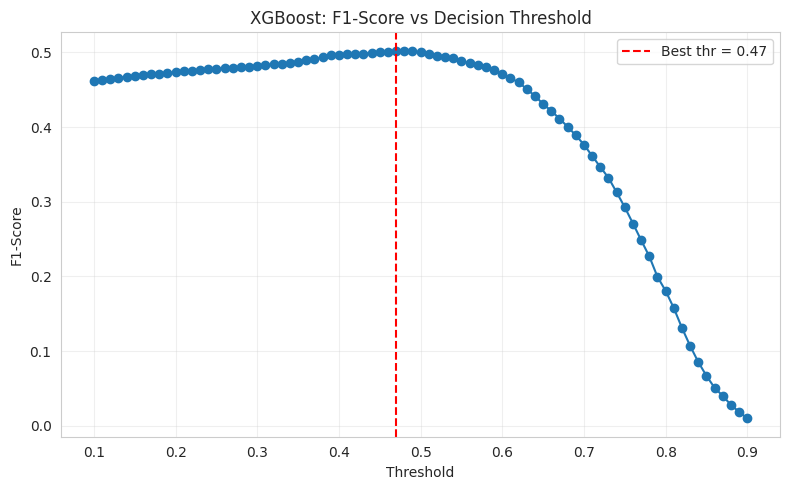

Saved: 11_xgb_threshold_tuning.png



In [ ]:
# ============================================================================
# SECTION 8B: THRESHOLD TUNING FOR XGBOOST
# ============================================================================

print("=" * 70)
print("SECTION 8B: THRESHOLD TUNING FOR XGBOOST")
print("=" * 70)
print()

# Predicted probabilities for the positive class (returned = 1)
y_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

tuning_results = []

for thr in thresholds:
    y_pred_thr = (y_proba_xgb >= thr).astype(int)

    # Metrics
    acc  = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr)
    rec  = recall_score(y_test, y_pred_thr)
    f1   = f1_score(y_test, y_pred_thr)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    spec = tn / (tn + fp)

    tuning_results.append({
        'threshold': thr,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'specificity': spec
    })

tuning_df = pd.DataFrame(tuning_results)

# Find threshold that maximises F1-score
best_row = tuning_df.loc[tuning_df['f1'].idxmax()]
best_thr = best_row['threshold']

print(f"Best threshold by F1-score: {best_thr:.2f}")
print()
print("Metrics at best threshold:")
print(f"Accuracy:    {best_row['accuracy']:.4f}")
print(f"Precision:   {best_row['precision']:.4f}")
print(f"Recall:      {best_row['recall']:.4f}")
print(f"F1-Score:    {best_row['f1']:.4f}")
print(f"Specificity: {best_row['specificity']:.4f}")
print()

# Confusion matrix at best threshold
y_pred_best = (y_proba_xgb >= best_thr).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best)
print("Confusion matrix at best threshold:")
print(cm_best)
print()

# Plot F1 vs threshold
plt.figure(figsize=(8, 5))
plt.plot(tuning_df['threshold'], tuning_df['f1'], marker='o')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Best thr = {best_thr:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('XGBoost: F1-Score vs Decision Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/11_xgb_threshold_tuning.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 11_xgb_threshold_tuning.png")
print()
